# Histogram of Oriented Gradients (HOG)

In [1]:
# Library Declarations
import time
import random
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from skimage import io, color
from math import floor

#PYNQ board overlay libraries
from pynq import Overlay
from pynq import allocate
from pynq import MMIO
import numpy as np
import time
import random

## Configuration

In [2]:
RUN_SW = False
RUN_HW = True

CELL_W = 16
CELL_H = 16
NUM_BINS = 9

MAX_IMG_H = 1000
MAX_IMG_W = 1000

IMAGE_PATH = "./ref.png"
NUM_IMAGES = 10

INT_TYPE = np.uint32
FLOAT_TYPE = np.float64

ADDR_OFFSET_CTRL  = 0x40000000
ADDR_OFFSET_DATA  = 0x40010000
ADDRESS_RANGE     = 0x10000

ADDR_INPUT_1      = 0x10   # lower 32-bits of input image buffer pointer
ADDR_INPUT_2      = 0x14   # upper 32-bits
ADDR_GX_OUT_1     = 0x1c   # lower 32-bits of Gx output buffer pointer
ADDR_GX_OUT_2     = 0x20   # upper 32-bits
ADDR_GY_OUT_1     = 0x28   # lower 32-bits of Gy output buffer pointer
ADDR_GY_OUT_2     = 0x2c   # upper 32-bits

#Address for Rows and Columns
ADDR_ROWS = 0x34
ADDR_COLS = 0x3c
ol = Overlay("./gradient_convolution.bit")

hog_data_ip = MMIO(ADDR_OFFSET_DATA, ADDRESS_RANGE)
hog_ctrl_ip = MMIO(ADDR_OFFSET_CTRL, ADDRESS_RANGE)

####### DO NOT CHANGE
CTRL_ADDR       = 0x00  # Control register address
START_VALUE     = 1<<0  # bit 0
STOP_VALUE      = 0x0   # bit 0
DONE_VALUE      = 1<<1  # bit 1
AUTO_RESTART    = 1<<7  # bit 7

## Building Block Definitions

In [3]:
# Preprocessing
def preprocess(raw_image):
    '''
    Converts to grayscale if needed and normalizes to [0, 1].
    Works whether input is already [0,1] float or [0,255] uint8.
    '''
    if raw_image.ndim == 3:
        image = color.rgb2gray(raw_image).astype(FLOAT_TYPE)
    else:
        image = raw_image.astype(FLOAT_TYPE)

    if image.max() > 1.0:
        image = image / 255.0

    return image

# Convolution
def convolution_python(image, kernel):
    ir, jr = image.shape
    result = np.copy(image)
    for i in range(1, ir - 1):
        for j in range(1, jr - 1):
            result[i, j] = np.sum(image[i-1:i+2, j-1:j+2] * kernel)
    return result

def compute_gradients(image):
    kernel_dx = np.array([[0,0,0],[-1,0,1],[0,0,0]])
    kernel_dy = np.array([[0,-1,0],[0,0,0],[0,1,0]])
    ix = convolution_python(image, kernel_dx)
    iy = convolution_python(image, kernel_dy)
    g = np.sqrt(ix**2 + iy**2)
    return ix, iy, g

def compute_gradients_hw(image):
    H, W = image.shape

    image_hw = np.ascontiguousarray(
        (image * 255).clip(0, 255).astype(np.uint8)
    )

    if H > MAX_IMG_H or W > MAX_IMG_W:
        raise ValueError(
            f"Image shape {H}x{W} exceeds HLS max size {MAX_IMG_H}x{MAX_IMG_W}"
        )

    if H < 3 or W < 3:
        raise ValueError("Image must be at least 3x3 for 3x3 gradient convolution.")

    in_buf = allocate(shape=(H, W), dtype=np.uint8)
    gx_buf = allocate(shape=(H, W), dtype=np.int16)
    gy_buf = allocate(shape=(H, W), dtype=np.int16)

    # Copy 2D image into 2D PYNQ buffer
    in_buf[:] = image_hw
    gx_buf[:] = 0
    gy_buf[:] = 0

    in_buf.flush()
    gx_buf.flush()
    gy_buf.flush()

    hog_ctrl_ip.write(ADDR_INPUT_1, in_buf.physical_address & 0xffffffff)
    hog_ctrl_ip.write(ADDR_INPUT_2, in_buf.physical_address >> 32)

    hog_ctrl_ip.write(ADDR_GX_OUT_1, gx_buf.physical_address & 0xffffffff)
    hog_ctrl_ip.write(ADDR_GX_OUT_2, gx_buf.physical_address >> 32)

    hog_ctrl_ip.write(ADDR_GY_OUT_1, gy_buf.physical_address & 0xffffffff)
    hog_ctrl_ip.write(ADDR_GY_OUT_2, gy_buf.physical_address >> 32)

    # Runtime shape registers
    hog_ctrl_ip.write(ADDR_ROWS, H)
    hog_ctrl_ip.write(ADDR_COLS, W)

    # Start IP
    hog_ctrl_ip.write(CTRL_ADDR, START_VALUE)

    while (hog_ctrl_ip.read(CTRL_ADDR) & DONE_VALUE) == 0:
        pass

    gx_buf.invalidate()
    gy_buf.invalidate()

    ix = np.array(gx_buf, dtype=FLOAT_TYPE)
    iy = np.array(gy_buf, dtype=FLOAT_TYPE)
    g = np.sqrt(ix**2 + iy**2)

    in_buf.freebuffer()
    gx_buf.freebuffer()
    gy_buf.freebuffer()

    return ix, iy, g

# Orientation Computation
def compute_orientation(ix, iy):
    # Return signed gradient orientation in degrees [0,360)
    theta = np.degrees(np.arctan2(iy, ix))
    theta[theta < 0] += 360
    return theta

# Cell Histogram Calculation
def compute_cell_histograms(theta, w, h, num_bins):
    hs, ws = theta.shape
    ir, jr = floor(hs/h) + 1, floor(ws/w) + 1
    histograms = [[None] * jr for _ in range(ir)]
    for i in range(ir):
        for j in range(jr):
            patch = theta[i*h : i*h + h, j*w : j*w + w]
            histograms[i][j] = np.histogram(patch, bins=num_bins, range=(0,360))[0]
    return histograms

def hog(raw_image, w=CELL_W, h=CELL_H, num_bins=NUM_BINS):
    timings = {}

    # Preprocessing
    t0 = time.perf_counter()
    image = preprocess(raw_image)
    image = image[:120, :160]
    timings['preprocess'] = (time.perf_counter() - t0) * 1e3

    # Convolution
    t0 = time.perf_counter()
    if RUN_HW:
        ix, iy, g = compute_gradients_hw(image)
    else:
        ix, iy, g = compute_gradients(image)
    timings['convolution'] = (time.perf_counter() - t0) * 1e3

    # Orientation
    t0 = time.perf_counter()
    theta = compute_orientation(ix, iy)
    timings['orientation'] = (time.perf_counter() - t0) * 1e3

    # Cell histograms
    t0 = time.perf_counter()
    histograms = compute_cell_histograms(theta, w, h, num_bins)
    timings['cell_histograms'] = (time.perf_counter() - t0) * 1e3

    return histograms, timings

# Flatten HOG feature vector
def flatten_hog(histograms):
    rows = []
    for row in histograms:
        for cell in row:
            rows.append(cell)
    return np.concatenate(rows)

# Similarity
def euclidean_metric(x, y):
    return np.linalg.norm(x - y)

def cosine_similarity(x, y):
    norm = np.linalg.norm(x) * np.linalg.norm(y)
    return 0.0 if norm == 0 else float(np.dot(x,y)/norm)

print("Building blocks defined.")

Building blocks defined.


## Load and Inspect Image

Image shape: (217, 262)
Image dtype: float64


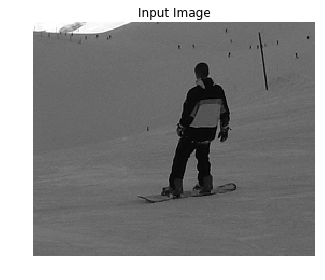

In [4]:
raw_image = io.imread(IMAGE_PATH)

if raw_image.ndim == 3:
    raw_image = color.rgb2gray(raw_image)

height, width = raw_image.shape

print(f"Image shape: {raw_image.shape}")
print(f"Image dtype: {raw_image.dtype}")

plt.figure(figsize=(5, 4))
plt.imshow(raw_image, cmap='gray')
plt.title("Input Image")
plt.axis('off')
plt.tight_layout()
plt.show()

## Hardware Profiling

--- Starting Hardware Profiling ---

Average over 10 runs (ms):
  preprocess          :    3.581 ms  (2.4%)
  convolution         :   21.585 ms  (14.4%)
  orientation         :   12.801 ms  (8.6%)
  cell_histograms     :  111.652 ms  (74.6%)
  TOTAL               :  149.619 ms


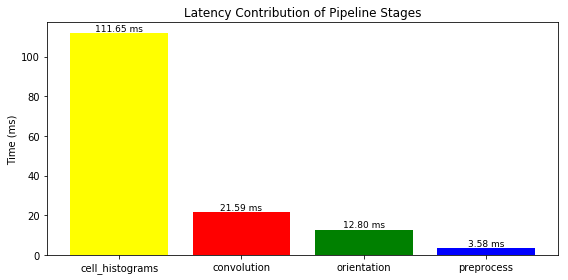

In [5]:
if RUN_HW:
    print("--- Starting Hardware Profiling ---")

#Run through the image NUM_IMAGES times to get an average
    all_timings = []
    for i in range(NUM_IMAGES):
        _, t = hog(raw_image, CELL_W, CELL_H, NUM_BINS)
        all_timings.append(t)

    stages = list(all_timings[0].keys())
    avg_t = {s: np.mean([r[s] for r in all_timings]) for s in stages}
    total = sum(avg_t.values())

    print(f"\nAverage over {NUM_IMAGES} runs (ms):")
    for s, v in avg_t.items():
        pct = 100 * v / total
        print(f"  {s:<20}: {v:8.3f} ms  ({pct:.1f}%)")
    print(f"  {'TOTAL':<20}: {total:8.3f} ms")

# Bar chart
colors = ['blue', 'red', 'green', 'yellow']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(stages, [avg_t[s] for s in stages], color=colors)

for bar, s in zip(bars, stages):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{avg_t[s]:.2f} ms',
        ha='center',
        va='bottom',
        fontsize=9
    )

ax.set_ylabel('Time (ms)')
ax.set_title('Latency Contribution of Pipeline Stages')
plt.tight_layout()
plt.show()

## Visualize Intermediate Outputs

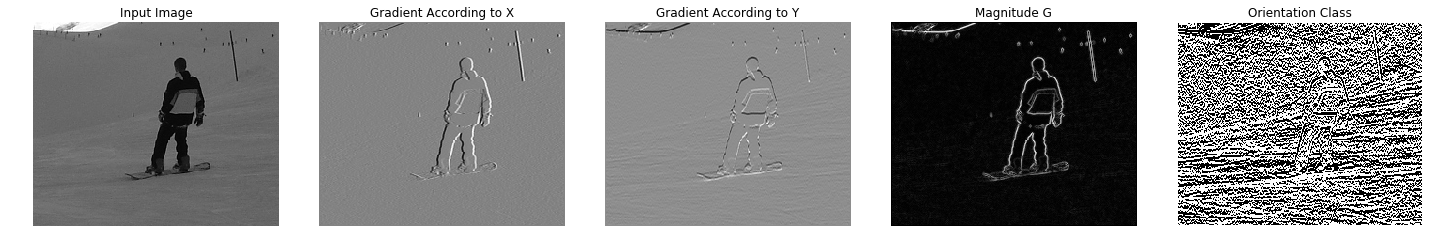

Timing breakdown:
preprocess: 6.191 ms
convolution: 24.089 ms
orientation: 13.480 ms
cell_histograms: 124.657 ms


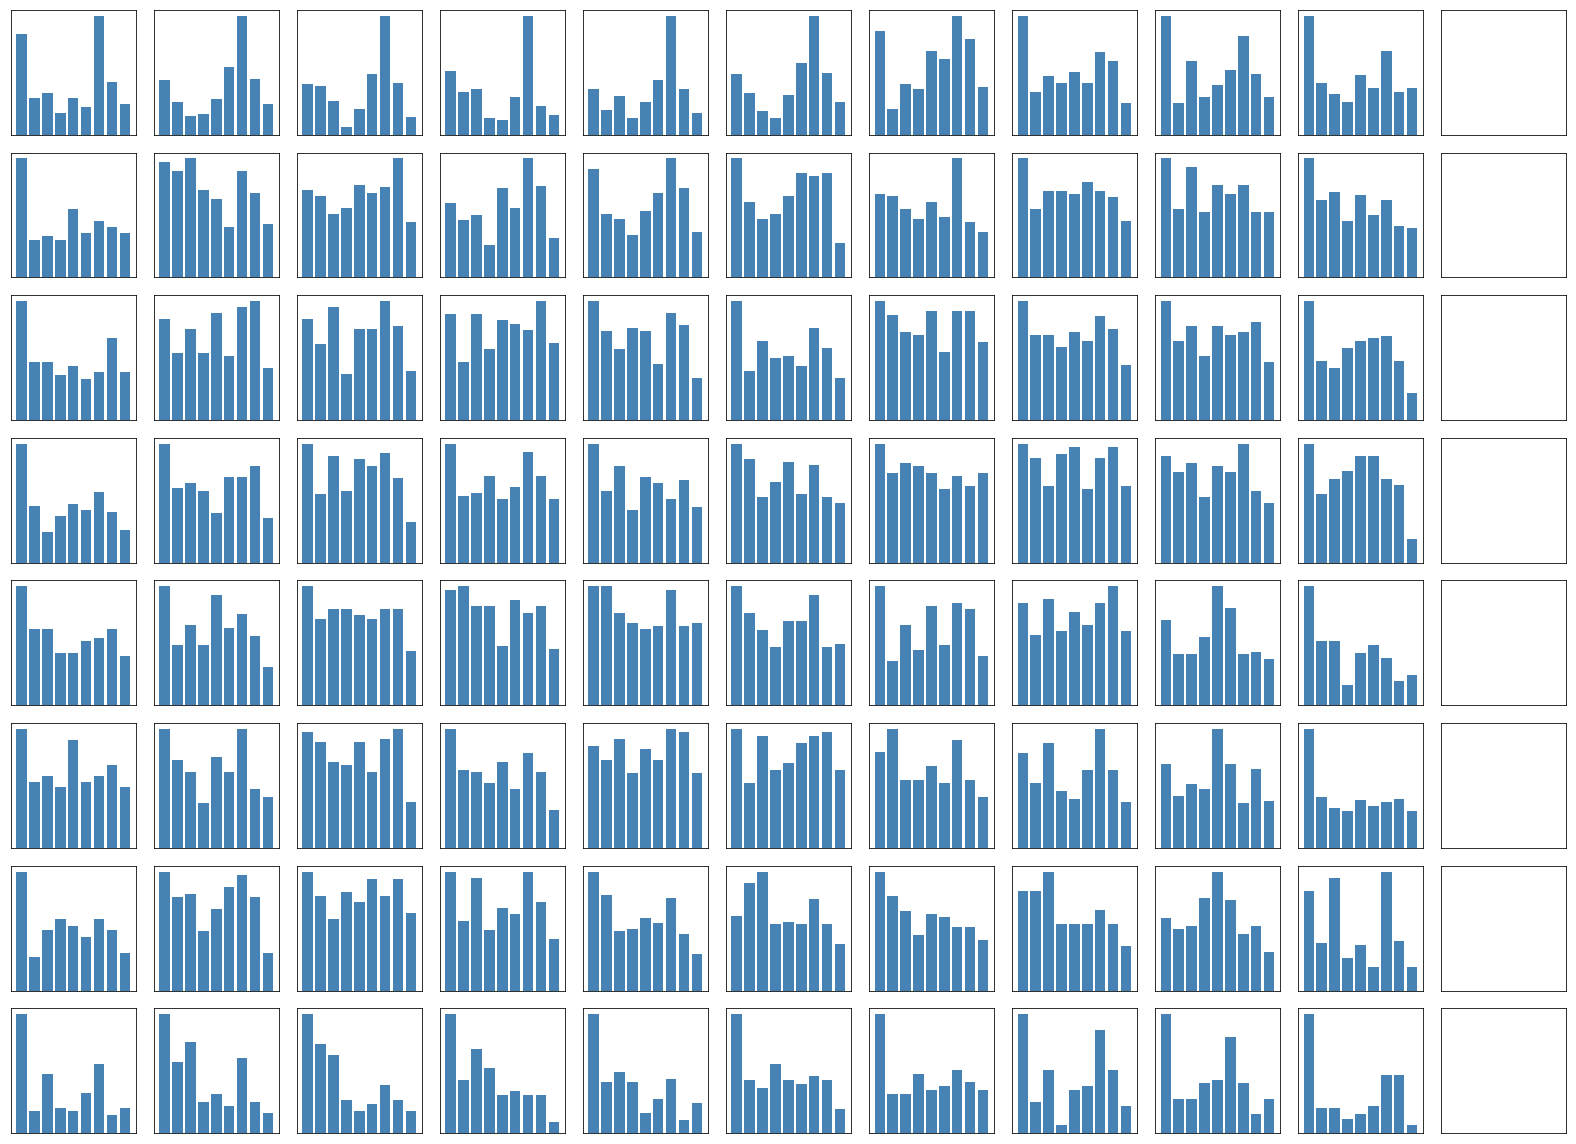

In [6]:
if RUN_HW:
    image = preprocess(raw_image)
    ix, iy, g = compute_gradients_hw(image)

    theta = compute_orientation(ix, iy)
    gc = np.where(theta <= 180, 1, 0)

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    titles = [
        'Input Image',
        'Gradient According to X',
        'Gradient According to Y',
        'Magnitude G',
        'Orientation Class'
    ]

    imgs = [image, ix, iy, g, gc]

    for ax, title, img in zip(axes, titles, imgs):
        ax.imshow(img, cmap='gray')
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    

    histograms, timings = hog(raw_image, CELL_W, CELL_H, NUM_BINS)

    print("Timing breakdown:")
    for stage, t_ms in timings.items():
        print(f"{stage}: {t_ms:.3f} ms")

    il = len(histograms)
    jl = len(histograms[0])

    fig, axes = plt.subplots(il, jl, figsize=(jl * 2, il * 2))

    axes = np.array(axes).reshape(il, jl)

    for i in range(il):
        for j in range(jl):
            ax = axes[i, j]
            ax.bar(range(NUM_BINS), histograms[i][j], color='steelblue')
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout()
    plt.show()